In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

data = pd.read_csv('close_prices.csv')

In [162]:
smoothed_data = pd.read_csv('smoothed_close_prices.csv')

In [142]:
# Δημιουργία καθυστερημένων τιμών (lags) για τη στήλη 'Smoothed Close Price'
for lag in range(1, 5):  # Δημιουργία 3 καθυστερημένων τιμών
    smoothed_data[f'smoothed_close_t-{lag}'] = smoothed_data['Smoothed Close Price'].shift(-lag)

smoothed_data.fillna(0, inplace=True)

smoothed_data.tail()

,Date,Close Price,Smoothed Close Price,smoothed_close_t-1,smoothed_close_t-2,smoothed_close_t-3,smoothed_close_t-4
6295,1999-11-05,88.31,87.217109,86.763078,86.399102,86.144136,86.012669
6296,1999-11-04,83.62,86.763078,86.399102,86.144136,86.012669,0.000000
6297,1999-11-03,81.50,86.399102,86.144136,86.012669,0.000000,0.000000
6298,1999-11-02,80.25,86.144136,86.012669,0.000000,0.000000,0.000000
6299,1999-11-01,77.62,86.012669,0.000000,0.000000,0.000000,0.000000


In [143]:
smoothed_data.head()

,Date,Close Price,Smoothed Close Price,smoothed_close_t-1,smoothed_close_t-2,smoothed_close_t-3,smoothed_close_t-4
0,2024-11-13,225.12,225.405344,225.466487,225.589532,225.775824,226.026544
1,2024-11-12,224.23,225.466487,225.589532,225.775824,226.026544,226.341164
2,2024-11-11,224.23,225.589532,225.775824,226.026544,226.341164,226.716854
3,2024-11-08,226.96,225.775824,226.026544,226.341164,226.716854,227.147451
4,2024-11-07,227.48,226.026544,226.341164,226.716854,227.147451,227.623096


In [144]:
smoothed_data['Date'] = pd.to_datetime(data['Date'])

# Χωρίζουμε τα δεδομένα σε εκπαίδευση και επικύρωση
validation_data = smoothed_data[smoothed_data['Date'].dt.year == 2024]  # Στοιχεία για επικύρωση (2024)
training_data = smoothed_data[smoothed_data['Date'].dt.year < 2024]     # Στοιχεία για εκπαίδευση (προηγούμενα έτη)

# Ορισμός χαρακτηριστικών και στόχου
X_train = training_data[['smoothed_close_t-1', 'smoothed_close_t-2', 'smoothed_close_t-3', 'smoothed_close_t-4']]
y_train = training_data['Smoothed Close Price']

X_val = validation_data[['smoothed_close_t-1', 'smoothed_close_t-2', 'smoothed_close_t-3', 'smoothed_close_t-4']]
y_val = validation_data['Smoothed Close Price']

# Δημιουργία του μοντέλου γραμμικής παλινδρόμησης και εκπαίδευση
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [145]:
# Προβλεψη στο σύνολο επικύρωσης
predictions = model.predict(X_val)

# Πρόβλεψη στο σύνολο εκπαίδευσης 
y_pred_train = model.predict(X_train)

In [146]:
# Υπολογισμός των μετρικών
mse_train = mean_squared_error(y_train, y_pred_train)
mse_val = mean_squared_error(y_val, predictions)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_val = mean_absolute_error(y_val, predictions)

print("Training MSE:", mse_train)
print("Validation MSE:", mse_val)
print("Training MAE:", mae_train)
print("Validation MAE:", mae_val)

Training MSE: 1.7705301358100882
Validation MSE: 0.019363640264797737
Training MAE: 0.20174070715826226
Validation MAE: 0.11260492168210008


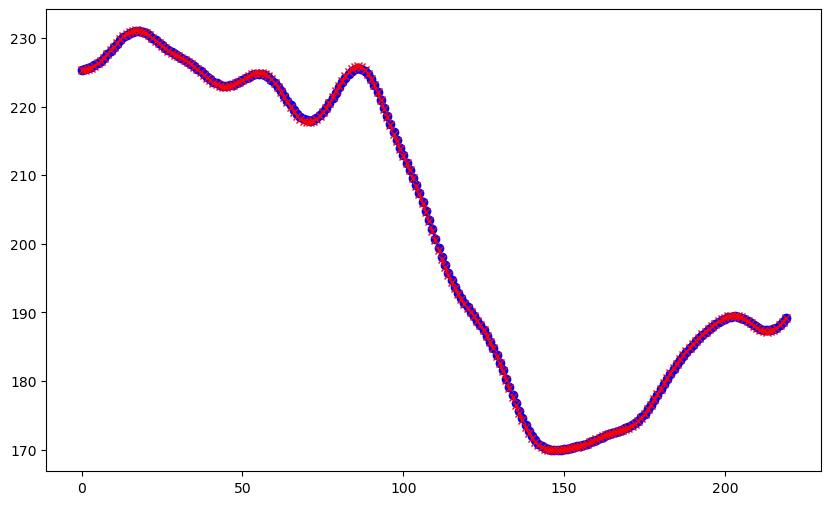

In [147]:
import matplotlib.pyplot as plt

# Γραφική απεικόνιση με πραγματικές και προβλεπόμενες τιμές στο σύνολο επικύρωσης
plt.figure(figsize=(10, 6))
plt.plot(y_val.reset_index(drop=True), label='Actual Values', color='blue', marker='o')
plt.plot(predictions, label='Predicted Values', color='red', linestyle='--', marker='x')

## Prediction

In [159]:
# παίρνουμε τις 4 τε΄λευταίεσ closing prices 
last_3_prices = smoothed_data['Smoothed Close Price'].head(4).values  

if len(last_3_prices) >= 4:
    features = last_3_prices[-4:]  
else:
    raise ValueError("Not enough data to create features for prediction.")

# προετοιμασία των features για prediction 
X_next = pd.DataFrame([features], columns=['smoothed_close_t-1', 'smoothed_close_t-2', 'smoothed_close_t-3', 'smoothed_close_t-4'])

# πρόβλεψη closing τιμής της επόμενης ημέρας
predicted_price = model.predict(X_next)

# Αποτέλεσμα πρόβλεψης
print(f"Predicted Close Price for next day: {predicted_price[0]}")

Predicted Close Price for next day: 225.2910810759472
